In [1]:
import json
import pickle
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from networkx.readwrite import json_graph

In [3]:
df = pd.read_json("phase4_pca_clusters.json",lines=True)
df.head()

,Title,BrandInfo.BrandName,ProductName,Category.Name.Value,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Description.LongProductName,Description.LongDesc,pathlist_names,Level1,...,Level4,raw_text,cleaned_text,dataset,embedding,yake_keywords,keybert_keywords,combined_keywords,HDBSCAN_Cluster,Cluster_Label
0,ASUS K31CD-IT049T PC 6th gen Intel® Core™ i7 i...,ASUS,K31CD-IT049T,PCs/Workstations,ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,"ASUS K31CD-IT049T, 3.4 GHz, 6th gen Intel® Cor...","Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",<b>Smart Multimedia Performance</b><br>\nVivoP...,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,...,None,ASUS K31CD-IT049T PC 6th gen Intel® Core™ i7 i...,asus k31cd-it049t pc 6th gen i7 i7-6700 16 gb ...,train,"[-0.0038826843, -0.0356898196, -0.0541902333, ...","[asus, vivopc, window, desktop, time, faster, ...","[hardware, it049t, menu, save, online, iterati...","[asus, vivopc, window, desktop, time, faster, ...",36,C36
1,HP 686915-A41 notebook spare part Keyboard,HP,686915-A41,Notebook Spare Parts,HP 686915-A41. Type: Keyboard. Keyboard langua...,"HP 686915-A41, Keyboard, Belgian, Keyboard bac...",Keyboard in midnight black finish with backlig...,,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,...,Notebook Spare Parts,HP 686915-A41 notebook spare part Keyboard HP ...,hp 686915-a41 notebook spare part keyboard hp ...,train,"[-0.0597511344, -0.0515312962, 0.0683662742000...","[keyboard, notebook, spare, pavilion, part, be...","[hp, keyboard, backlight, a41, compatibility, ...","[keyboard, notebook, spare, pavilion, part, be...",24,C24
2,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,C2G,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,Fibre Optic Cables,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,Get the performance you demand at a price that...,Computers & Electronics>Computer Cables>Fibre ...,Computers & Electronics,...,None,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,c2g 1m plenum-rated duplex single-mode fiber p...,train,"[0.0158798192, -0.0839087293, 0.03860477730000...","[cable, fiber, patch, connector, duplex, singl...","[fibre, gigabit, duplex, plenum, multicolored,...","[cable, fiber, patch, connector, duplex, singl...",14,C14
3,HP FA889AA Battery,HP,FA889AA,Handheld Mobile Computer Spare Parts,"HP FA889AA. Product type: Battery, Product col...","HP FA889AA, Battery, White, Lithium-Ion (Li-Io...","1100 mAh, Lithium Ion, Standard Battery",Keeping an extra source of power nearby means ...,Computers & Electronics>Computers>Handheld Mob...,Computers & Electronics,...,None,HP FA889AA Battery HP FA889AA Handheld Mobile ...,hp fa889aa battery hp fa889aa handheld mobile ...,train,"[-0.0827628672, 0.0492046289, 0.0070899236, -0...","[battery, mah, lithium-ion, li-ion, product, w...","[hp, fa889aa, lithium, type, spare, power, ipa...","[battery, mah, lithium-ion, li-ion, product, w...",-1,Noise
4,Lenovo ThinkStation C30 Intel® Xeon® E5 Family...,Lenovo,C30,PCs/Workstations,Lenovo ThinkStation C30. Processor frequency: ...,"Lenovo ThinkStation C30, 2 GHz, Intel® Xeon® E...","Intel Xeon E5-2620 (15M Cache, 2.00 GHz, 7.20 ...",The C30 builds on its award-winning design as ...,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,...,None,Lenovo ThinkStation C30 Intel® Xeon® E5 Family...,lenovo thinkstation c30 e5 family e5-2620 4 gb...,train,"[-0.0086111259, -0.0465559736, -0.055984024, -...","[workstation, professional, thinkstation, memo...","[lenovo, 300gb, e5, thinkstation, dual, certif...","[workstation, professional, thinkstation, memo...",36,C36


In [4]:
# ---------------------------
INPUT = "phase4_pca_clusters.json"        # <-- Phase 4 output
GRAPH_OUT = "phase5_taxonomy_graph.gpickle"   # saved via pickle (version-agnostic)
GRAPH_JSON_OUT = "phase5_taxonomy_graph.json" # node-link JSON (web-friendly)
TREE_JSON_OUT = "phase5_taxonomy_tree.json"   # nested L1->L2->L3 tree with clusters
CLUSTER_SUMMARY_OUT = "phase5_cluster_summary.csv"

INCLUDE_LEVEL4 = True                      # attach Level4/Product leaves for context
COLLAPSE_LEVEL4 = True                     # collapse many leaves into a "+N products" node
MAX_LEAVES_PER_CLUSTER = 15                # threshold for collapsing
N_TERMS_PER_CLUSTER = 5                    # TF-IDF terms per cluster label
EXCLUDE_BRANDS = True                      # drop brand tokens from labels (set False to allow)
NGRAMS = (1, 2)                            # 1–2 grams read well
MIN_DF = 3                                 # ignore very rare terms in TF-IDF
MAX_DF = 0.7                               # ignore very common terms in TF-IDF


In [5]:
# Ensure output folder exists (if you pass paths with folders)
for p in [GRAPH_OUT, GRAPH_JSON_OUT, TREE_JSON_OUT, CLUSTER_SUMMARY_OUT]:
    Path(p).parent.mkdir(parents=True, exist_ok=True)


In [6]:
# Load clustered data
# WHAT: Read Phase 4 results and remove noise (-1).
# WHY: Only stable clusters should influence naming and the tree.
# ---------------------------
df = pd.read_json(INPUT, lines=True)
df = df[df["HDBSCAN_Cluster"] >= 0].reset_index(drop=True)

# Normalize fields we’ll use
for col in ["cleaned_text", "Level1", "Level2", "Level3", "Level4", "ProductName", "BrandInfo.BrandName"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)
# Sometimes Level4 literal "None" sneaks in as a string
if "Level4" in df.columns:
    df["Level4"] = df["Level4"].replace("None", "")


In [7]:
# ---------------------------
# Brand blacklist (optional)
# WHAT: Avoid labels like "hp, asus" if you want topic names.
# ---------------------------
brand_blacklist = set()
if EXCLUDE_BRANDS and "BrandInfo.BrandName" in df.columns:
    brand_blacklist = {b.strip().lower() for b in df["BrandInfo.BrandName"].unique() if b}


In [8]:
# TF-IDF cluster naming
# WHAT: Score terms by TF-IDF; for each cluster take the mean vector and pick top-N terms.
# WHY: Highlights terms distinctive to that cluster (not just frequent globally).
# ---------------------------
vectorizer = TfidfVectorizer(
    ngram_range=NGRAMS,
    min_df=MIN_DF,
    max_df=MAX_DF,
    stop_words="english",
)
X = vectorizer.fit_transform(df["cleaned_text"])
terms = np.array(vectorizer.get_feature_names_out())


In [11]:
terms

array(['001', '001 battery', '001 display', ..., 'zooming',
       'zooming rotating', 'zooming scrolling'], dtype=object)

In [12]:
cluster_names = {}
cluster_top_terms = {}

groups = df.groupby("HDBSCAN_Cluster").groups  # indices per cluster
for cid, idxs in groups.items():
    rows = X[list(idxs)]
    scores = rows.mean(axis=0).A1 if rows.shape[0] else np.zeros(X.shape[1])  # mean TF-IDF across docs
    order = np.argsort(scores)[::-1]

    selected = []
    for j in order:
        t = terms[j].strip()
        tl = t.lower()
        if EXCLUDE_BRANDS and tl in brand_blacklist:
            continue
        if tl.isdigit() or len(tl) <= 2:
            continue
        selected.append(t)
        if len(selected) >= N_TERMS_PER_CLUSTER:
            break

    if not selected:  # fallback if everything got filtered
        selected = list(terms[order[:N_TERMS_PER_CLUSTER]])

    cluster_names[cid] = ", ".join(selected)
    cluster_top_terms[cid] = selected

In [13]:
# ---------------------------
# Build hierarchical graph
# WHAT: Level1 → Level2 → Level3 → Cluster (+ optional Level4 leaves)
# WHY: Keeps human taxonomy as spine; discovered clusters live under Level3.
# ---------------------------
G = nx.DiGraph()

In [14]:
def add_node(key, label, ntype, **attrs):
    if key not in G:
        G.add_node(key, label=label, type=ntype, **attrs)

cluster_to_products = defaultdict(list)  # collect L4 leaves per cluster

for cid, sub in df.groupby("HDBSCAN_Cluster"):
    c_key = f"CLUSTER::{cid}"
    c_label = f"{cid}: {cluster_names.get(cid, '')}"
    add_node(
        c_key, c_label, "cluster",
        cluster_id=int(cid), size=int(len(sub)),
        top_terms=cluster_top_terms.get(cid, []),
    )

    for _, row in sub.iterrows():
        l1 = row["Level1"].strip()
        l2 = row["Level2"].strip()
        l3 = row["Level3"].strip()

        k1 = f"L1::{l1}"
        k2 = f"L2::{l1}>{l2}"
        k3 = f"L3::{l1}>{l2}>{l3}"

        add_node(k1, l1, "level1")
        add_node(k2, l2, "level2")
        add_node(k3, l3, "level3")

        G.add_edge(k1, k2)
        G.add_edge(k2, k3)
        G.add_edge(k3, c_key)

        # stash Level4/product leaf names; attach later so we can collapse
        if INCLUDE_LEVEL4:
            leaf = row["Level4"].strip() if "Level4" in row and row["Level4"].strip() else row["ProductName"].strip()
            if leaf:
                cluster_to_products[cid].append(leaf)

In [26]:
cluster_to_products[cid]

['Server/Workstation Motherboards',
 'AS-2042G-TRF',
 'Server/Workstation Motherboards',
 'Motherboards',
 'A+ Server 1012A-M73RF',
 '1026T-6RFT+',
 'SuperServer 2027TR-HTRF',
 'Server/Workstation Motherboards',
 'SYS-5017GR-TF-FM275',
 '6046T-TUF',
 'Server/Workstation Motherboards',
 'SuperServer 1029GQ-TNRT',
 'RS120-E5/PA4',
 'Motherboards',
 'Motherboards',
 'A+ Server 1023US-TR4']

In [19]:
cluster_to_products

defaultdict(list,
            {0: ['1Y, f/ TS-453 Pro',
              '2Y, f/ TS-EC1680U-E3-4GE-R2',
              'ONSITE1Y-TS-873U-16G-PL',
              '5Y f/ REXP-1600U (IT)',
              '3Y f/ TS-EC1680U (CH)',
              '2Y, f/ TS-670 Pro',
              '1Y, f/ REXP-1200U-RP',
              '3Y, f/ TVS-671-PT-4G',
              '1Y, f/ TVS-863+-16G',
              '3Y, f/ TS-1273U-RP-8G',
              '3Y, f/ SS-853 Pro',
              '1Y, f/ TS-870 Pro',
              '5Y f/ TS-EC1279U (IT)',
              '5Y f/ TS-670',
              '2Y, f/ TS-253A-8G',
              '2Y, f/ TVS-463',
              '3Y f/ TS-16-SAS (CH)',
              '2Y, f/ TVS-873-16G'],
             1: ['Earhook Headphones SHS8100/98',
              'Headphones',
              'Headphones',
              'Micro System CMT-A50',
              'Headphones with mic SHE5305WT/00',
              'HA-FR15-Z-E Colourful inner ear headphones with remote & mic',
              'Headphones with mic SHL52

In [27]:
cluster_to_products.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 'A+ Server 1023US-TR4'])

In [21]:
cluster_to_products.items()

dict_items([(0, ['1Y, f/ TS-453 Pro', '2Y, f/ TS-EC1680U-E3-4GE-R2', 'ONSITE1Y-TS-873U-16G-PL', '5Y f/ REXP-1600U (IT)', '3Y f/ TS-EC1680U (CH)', '2Y, f/ TS-670 Pro', '1Y, f/ REXP-1200U-RP', '3Y, f/ TVS-671-PT-4G', '1Y, f/ TVS-863+-16G', '3Y, f/ TS-1273U-RP-8G', '3Y, f/ SS-853 Pro', '1Y, f/ TS-870 Pro', '5Y f/ TS-EC1279U (IT)', '5Y f/ TS-670', '2Y, f/ TS-253A-8G', '2Y, f/ TVS-463', '3Y f/ TS-16-SAS (CH)', '2Y, f/ TVS-873-16G']), (1, ['Earhook Headphones SHS8100/98', 'Headphones', 'Headphones', 'Micro System CMT-A50', 'Headphones with mic SHE5305WT/00', 'HA-FR15-Z-E Colourful inner ear headphones with remote & mic', 'Headphones with mic SHL5205PP/10', 'Headphones', 'Headphones', 'CINEARPRO', 'MDR-100AAP', 'Headsets', 'Headsets', 'Headphones', 'Charisma', 'Headphones', 'Headphones', 'Headphones with mic SHE3855RG/00']), (2, ['CP03OSSEH815', 'CP03OSSEH601', 'eSP: 05 YRs CP OS Serv for EB-4550', 'CP1EOSSECE46', 'CP03RTBSCD49', '4 year CoverPlus Pack 15 VI Lamp', 'CP05OSSEH568', 'CP03RTBSCC

In [24]:
cid

37

In [29]:
# Attach Level4 leaves (collapse if many)
if INCLUDE_LEVEL4:
    for cid, products in cluster_to_products.items():
        c_key = f"CLUSTER::{cid}"
        if not products:
            continue

        # dedupe while preserving order
        seen, unique_products = set(), []
        for p in products:
            if p not in seen:
                seen.add(p)
                unique_products.append(p)

        if COLLAPSE_LEVEL4 and len(unique_products) > MAX_LEAVES_PER_CLUSTER:
            sum_key = f"LEAF::summary::{cid}"
            add_node(sum_key, f"+{len(unique_products)} products", "leaf", count=len(unique_products))
            G.add_edge(c_key, sum_key)
        else:
            for i, p in enumerate(unique_products[:MAX_LEAVES_PER_CLUSTER]):
                leaf_key = f"LEAF::{cid}::{i}"
                add_node(leaf_key, p[:100], "leaf")  # truncate long names to keep drawings tidy
                G.add_edge(c_key, leaf_key)


In [ ]:

# Export artifacts (version-agnostic)

# 1) Binary graph via Python pickle (works on any NetworkX version)
with open(GRAPH_OUT, "wb") as f:
    pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

# 2) Node-link JSON (great for web/Phase 7; no pickle needed)
with open(GRAPH_JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(json_graph.node_link_data(G), f, ensure_ascii=False, indent=2)


C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [31]:
# 3) Nested JSON: L1→L2→L3→clusters (with top_terms & sample products)
def nested_dict(): return defaultdict(nested_dict)
tree = nested_dict()

for cid, sub in df.groupby("HDBSCAN_Cluster"):
    meta = {
        "cluster_id": int(cid),
        "label": cluster_names.get(cid, ""),
        "size": int(len(sub)),
        "top_terms": cluster_top_terms.get(cid, []),
        "products": [],
    }
    if INCLUDE_LEVEL4:
        # keep at most MAX_LEAVES_PER_CLUSTER here for compactness
        meta["products"] = (list(dict.fromkeys(cluster_to_products.get(cid, [])))
                            [:MAX_LEAVES_PER_CLUSTER])

    # mount once under the first seen L1→L2→L3 (or loop unique L3 paths if you prefer)
    r = sub.iloc[0]
    node = tree[r["Level1"]][r["Level2"]][r["Level3"]].setdefault("clusters", [])
    node.append(meta)


In [32]:

with open(TREE_JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(tree, f, ensure_ascii=False, indent=2)


In [34]:
# 4) Flat CSV summary for quick QA
summary = (
    df.groupby("HDBSCAN_Cluster")
      .agg(size=("HDBSCAN_Cluster", "size"),
           sample_L1=("Level1", "first"),
           sample_L2=("Level2", "first"),
           sample_L3=("Level3", "first"))
      .reset_index()
)
summary["label"] = summary["HDBSCAN_Cluster"].map(cluster_names)
summary["top_terms"] = summary["HDBSCAN_Cluster"].map(lambda c: " | ".join(cluster_top_terms.get(c, [])))
summary.to_csv(CLUSTER_SUMMARY_OUT, index=False)

print("Phase 5 complete")
print("Graph (pickle):", GRAPH_OUT)
print("Graph (node-link JSON):", GRAPH_JSON_OUT)
print("Tree JSON:", TREE_JSON_OUT)
print("Cluster summary CSV:", CLUSTER_SUMMARY_OUT)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Sample labels:")
for cid in list(groups.keys())[:5]:
    print(f"  Cluster {cid}: {cluster_names[cid]}")

Phase 5 complete
Graph (pickle): phase5_taxonomy_graph.gpickle
Graph (node-link JSON): phase5_taxonomy_graph.json
Tree JSON: phase5_taxonomy_tree.json
Cluster summary CSV: phase5_cluster_summary.csv
Nodes: 188 Edges: 235
Sample labels:
  Cluster 0: warranty, extended warranty, warranty service, extended, year
  Cluster 1: headphone, ear, intraaural, headset, binaural
  Cluster 2: coverplus, year, extension epson, warranty, coverplus extended
  Cluster 3: extension lenovo, service, year, 24x7, extension
  Cluster 4: nbd, prosupport, business day, day, support


C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


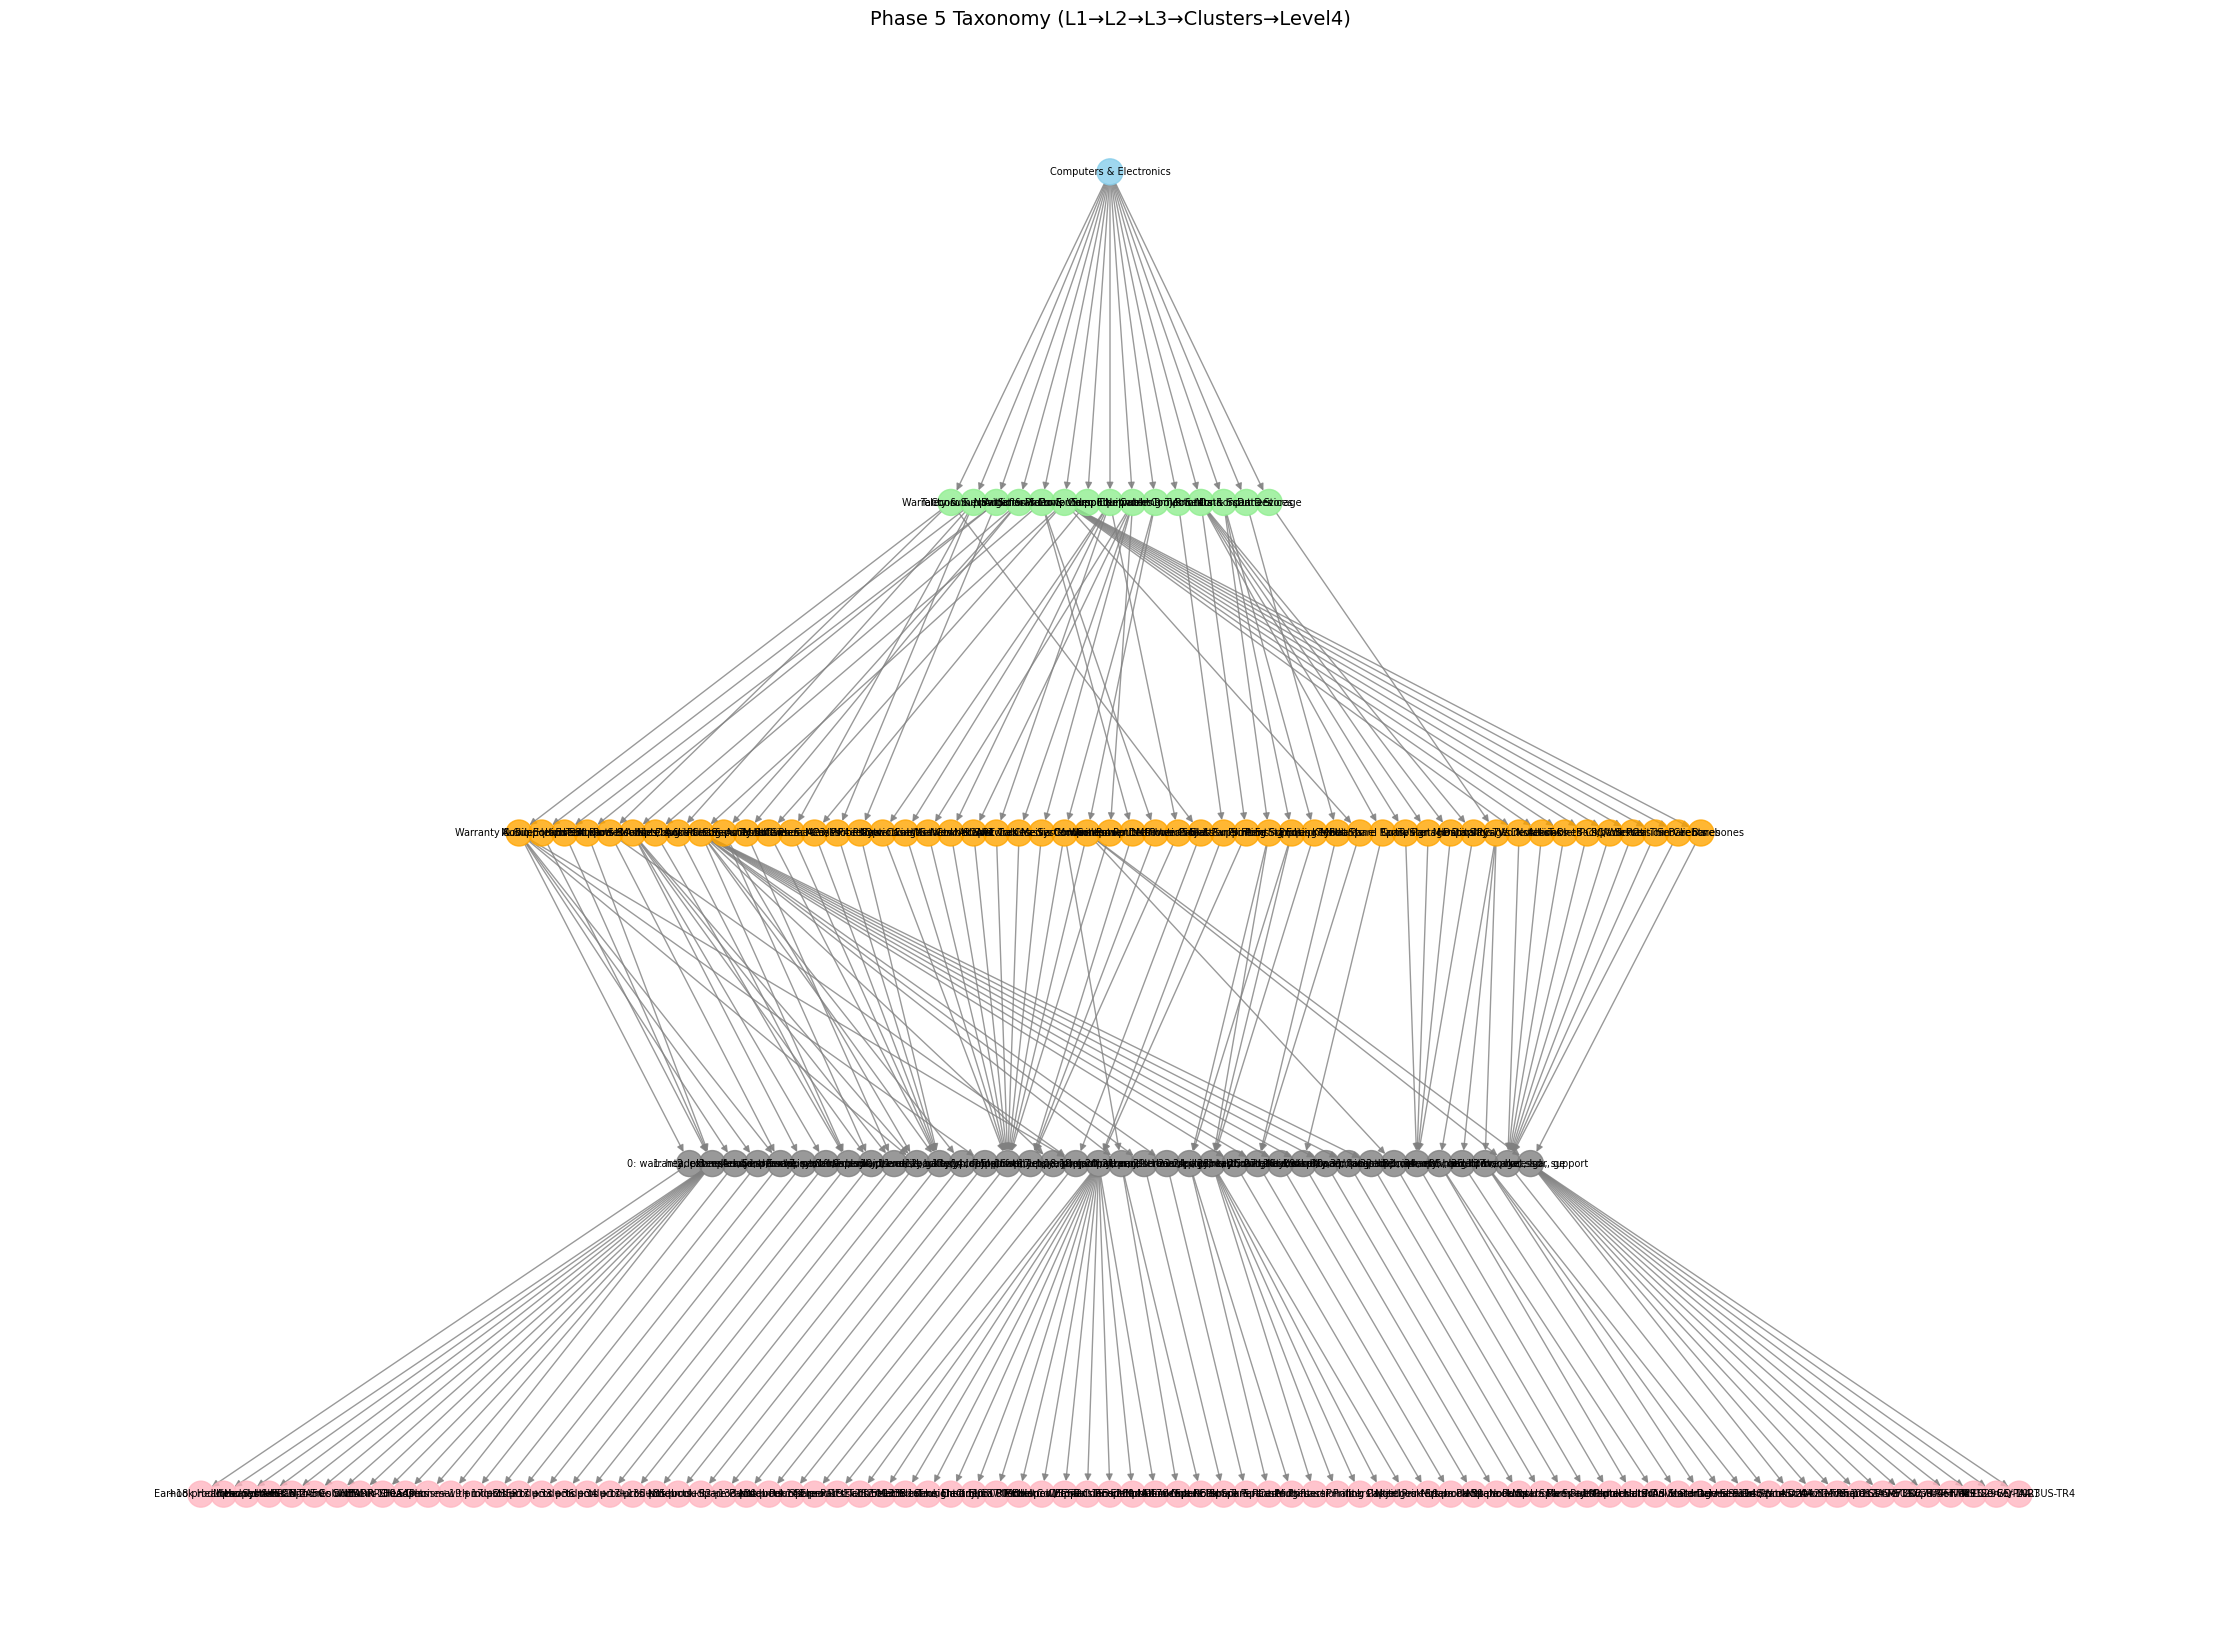

In [35]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from networkx.readwrite import json_graph
from collections import defaultdict

# Load graph (created in Phase 5)
with open("phase5_taxonomy_graph.json", "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)

# Assign a drawing level by node 'type'
type_to_level = {"level1":1, "level2":2, "level3":3, "cluster":4, "leaf":5}
levels = defaultdict(list)
for n, d in G.nodes(data=True):
    lvl = type_to_level.get(d.get("type"), 6)
    d["level"] = lvl
    levels[lvl].append(n)

# Simple top-down layout
pos = {}
for lvl in sorted(levels):
    nodes = levels[lvl]
    xs = list(range(len(nodes)))
    xs = [x - len(nodes)/2 for x in xs]
    for x, n in zip(xs, nodes):
        pos[n] = (x, -lvl)

# Colors by type
color_map = {"level1":"skyblue", "level2":"lightgreen", "level3":"orange", "cluster":"gray", "leaf":"lightpink"}
node_colors = [color_map.get(G.nodes[n].get("type"), "lightgrey") for n in G.nodes()]

plt.figure(figsize=(22,16))
nx.draw(G, pos, with_labels=False, node_size=350, node_color=node_colors, edge_color="gray", alpha=0.8)
labels = {n: (G.nodes[n].get("label") or "")[:24] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7)
plt.title("Phase 5 Taxonomy (L1→L2→L3→Clusters→Level4)", fontsize=14)
plt.axis("off")
plt.show()


In [37]:
import json

with open("phase5_taxonomy_tree.json", "r", encoding="utf-8") as f:
    tree = json.load(f)

def preview_tree(tree, max_l1=2, max_l2=2, max_l3=2, max_clusters=3, max_products=3):
    
    for i, (l1, L2) in enumerate(tree.items()):
        if i >= max_l1: break
        print(l1)
        for j, (l2, L3) in enumerate(L2.items()):
            if j >= max_l2: break
            print("  └─", l2)
            for k, (l3, payload) in enumerate(L3.items()):
                if k >= max_l3: break
                if "clusters" not in payload: 
                    continue
                print("      └─", l3)
                for m, c in enumerate(payload["clusters"][:max_clusters]):
                    print(f"          • Cluster {c['cluster_id']}: {c['label']} (size={c['size']})")
                    if c.get("products"):
                        for p in c["products"][:max_products]:
                            print("              -", p)

# preview_tree(tree)
preview_tree(tree, max_l1=999, max_l2=999, max_l3=999, max_clusters=999, max_products=999)



Computers & Electronics
  └─ Warranty & Support
      └─ Warranty & Support Extensions
          • Cluster 0: warranty, extended warranty, warranty service, extended, year (size=18)
              - 1Y, f/ TS-453 Pro
              - 2Y, f/ TS-EC1680U-E3-4GE-R2
              - ONSITE1Y-TS-873U-16G-PL
              - 5Y f/ REXP-1600U (IT)
              - 3Y f/ TS-EC1680U (CH)
              - 2Y, f/ TS-670 Pro
              - 1Y, f/ REXP-1200U-RP
              - 3Y, f/ TVS-671-PT-4G
              - 1Y, f/ TVS-863+-16G
              - 3Y, f/ TS-1273U-RP-8G
              - 3Y, f/ SS-853 Pro
              - 1Y, f/ TS-870 Pro
              - 5Y f/ TS-EC1279U (IT)
              - 5Y f/ TS-670
              - 2Y, f/ TS-253A-8G
          • Cluster 2: coverplus, year, extension epson, warranty, coverplus extended (size=19)
              - CP03OSSEH815
              - CP03OSSEH601
              - eSP: 05 YRs CP OS Serv for EB-4550
              - CP1EOSSECE46
              - CP03RTBSCD49
          

{'CLUSTER::0': Text(-19.0, -4, '0: warranty, extended wa'),
 'L1::Computers & Electronics': Text(-0.5, -1, 'Computers & Electronics'),
 'L2::Computers & Electronics>Warranty & Support': Text(-7.5, -2, 'Warranty & Support'),
 'L3::Computers & Electronics>Warranty & Support>Warranty & Support Extensions': Text(-26.5, -3, 'Warranty & Support Exten'),
 'CLUSTER::1': Text(-18.0, -4, '1: headphone, ear, intra'),
 'L2::Computers & Electronics>Telecom & Navigation': Text(-6.5, -2, 'Telecom & Navigation'),
 'L3::Computers & Electronics>Telecom & Navigation>Mobile Headsets': Text(-25.5, -3, 'Mobile Headsets'),
 'L2::Computers & Electronics>Consumer Audio & Video Equipment': Text(-5.5, -2, 'Consumer Audio & Video E'),
 'L3::Computers & Electronics>Consumer Audio & Video Equipment>Audio Equipment Parts & Accessories': Text(-24.5, -3, 'Audio Equipment Parts & '),
 'L3::Computers & Electronics>Consumer Audio & Video Equipment>Home Audio Sets': Text(-23.5, -3, 'Home Audio Sets'),
 'CLUSTER::2': Text(

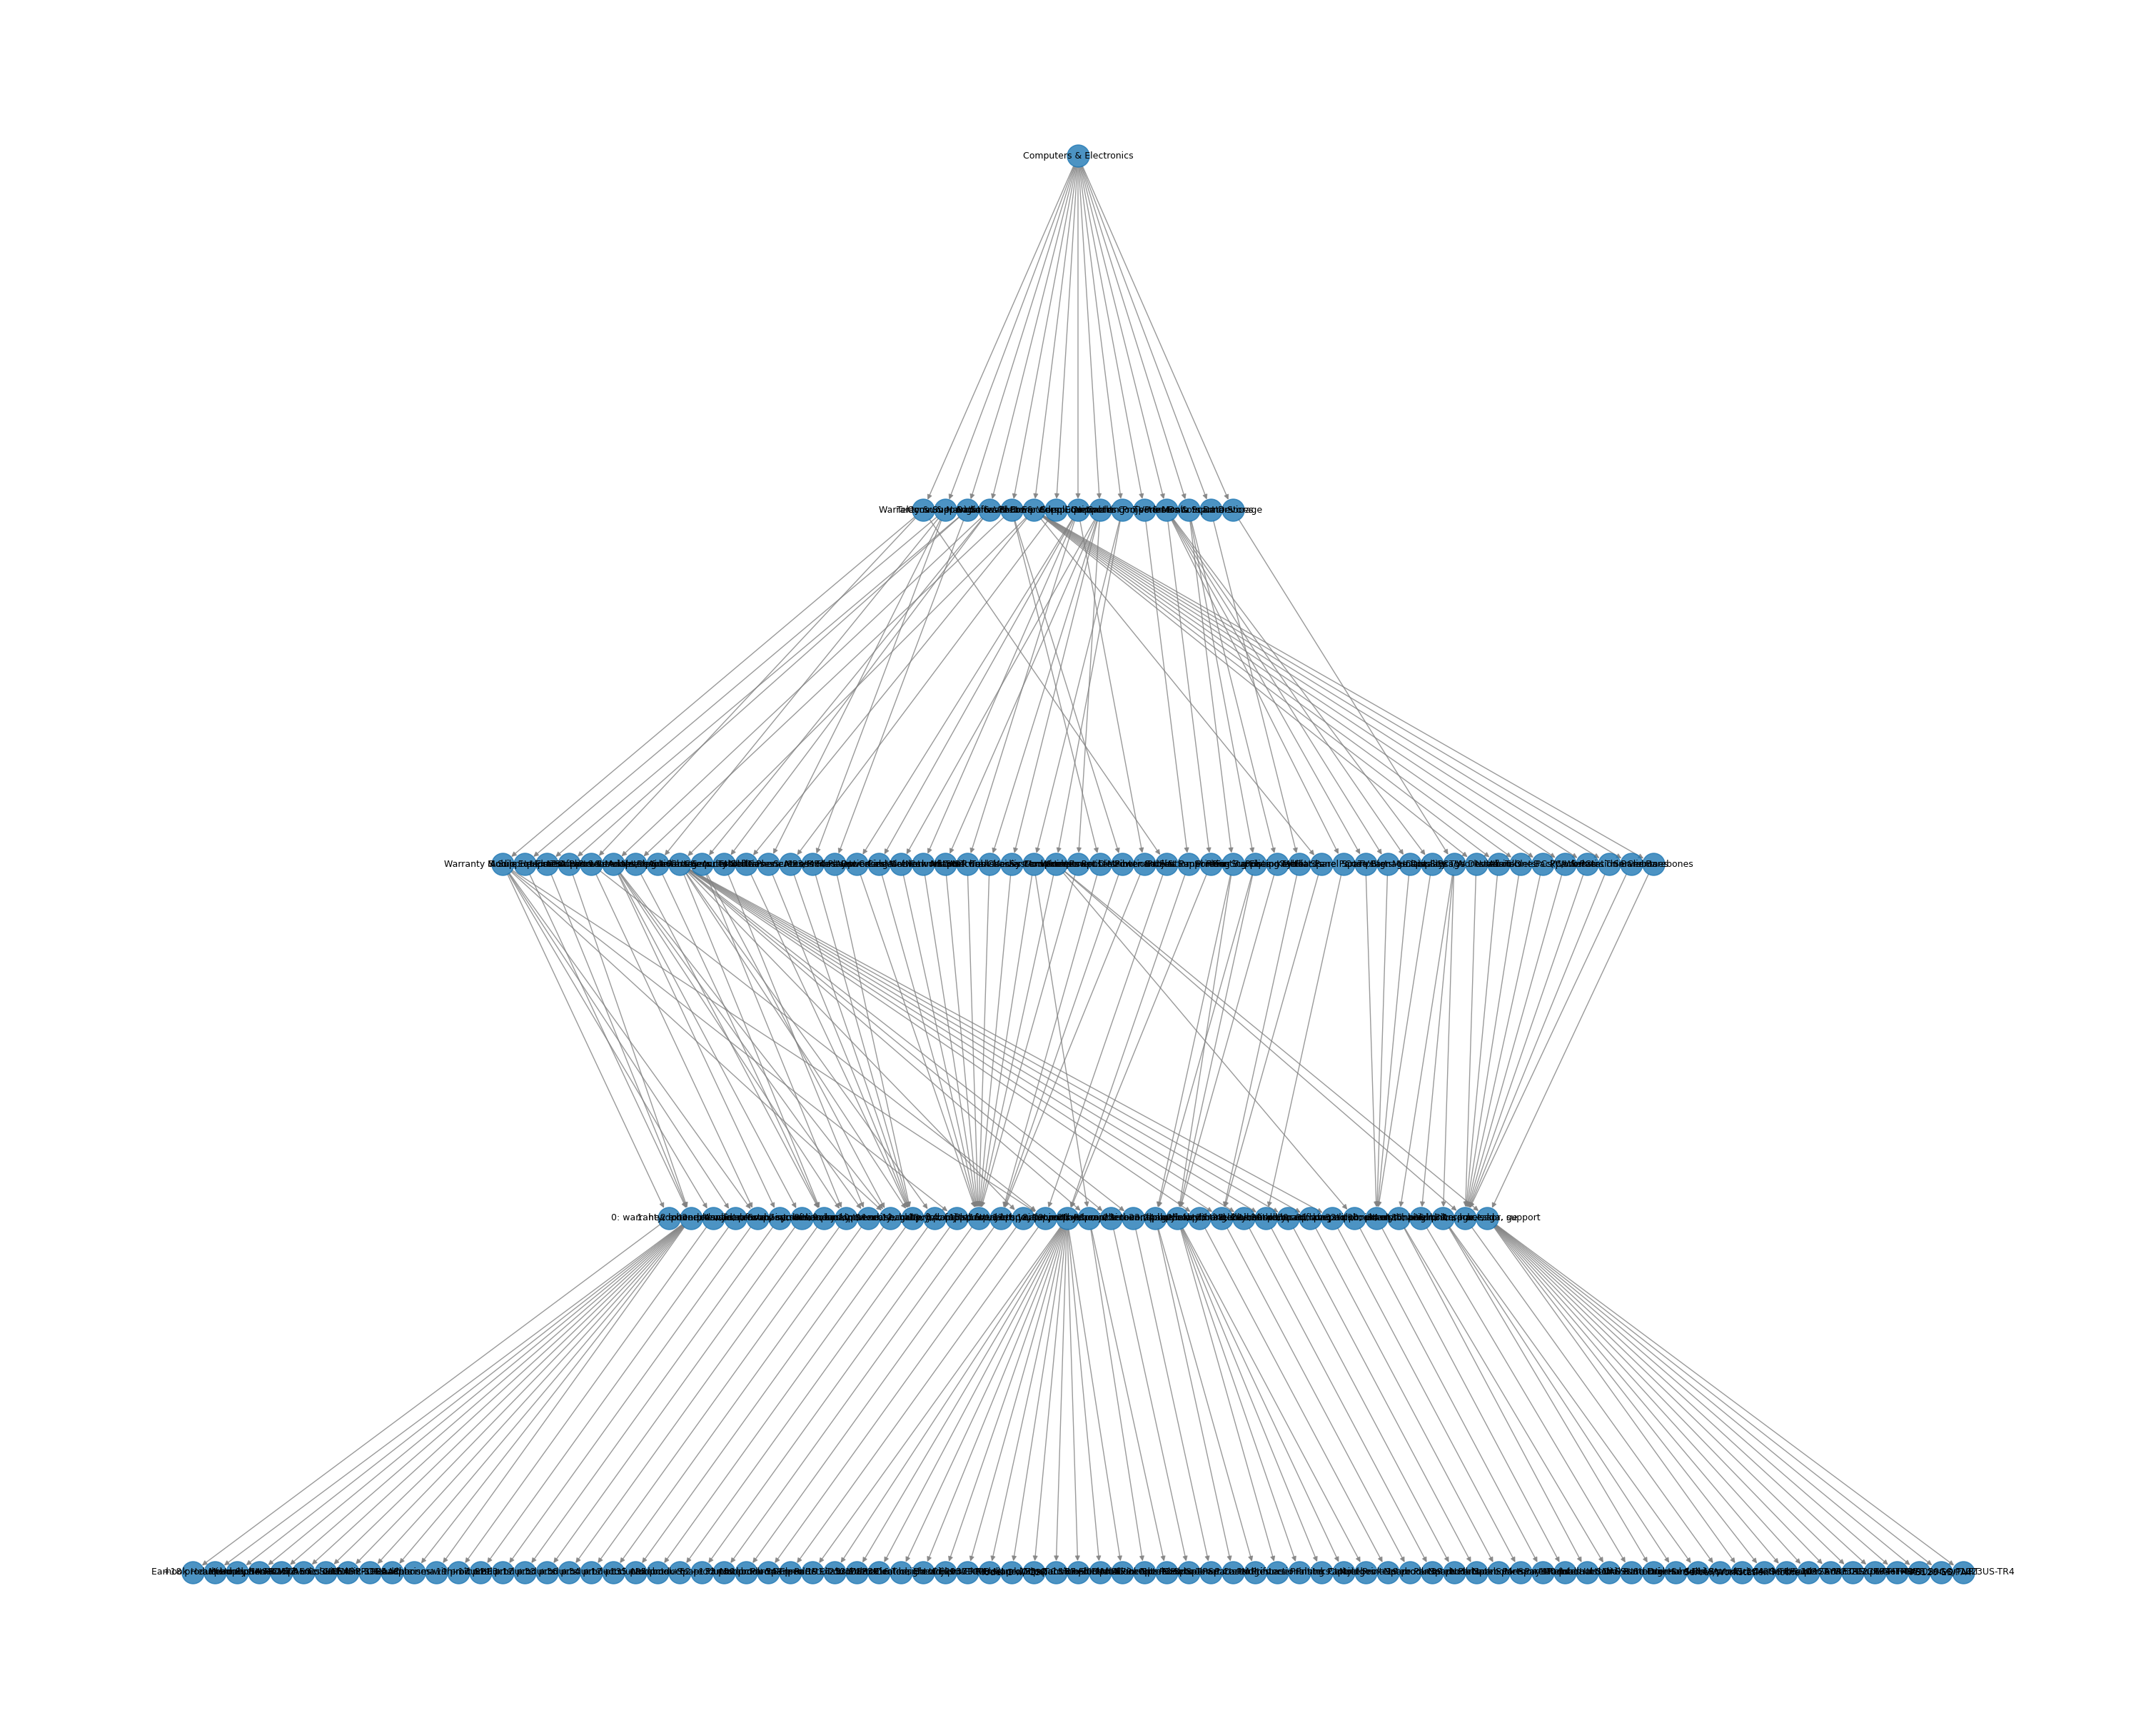

In [38]:
plt.figure(figsize=(30, 24))   # bigger canvas
nx.draw(G, pos, node_size=500, edge_color="gray", alpha=0.8)
nx.draw_networkx_labels(G, pos, labels, font_size=9)


In [31]:
import json
import pickle
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
# ---------------------------
# Settings (edit here)
# ---------------------------
INPUT = "phase4_pca_clusters.json"            # <-- Phase 4 output
GRAPH_OUT = "phase5_taxonomy_graph.gpickle"   # saved via pickle (version-agnostic)
GRAPH_JSON_OUT = "phase5_taxonomy_graph.json" # node-link JSON (web-friendly)
TREE_JSON_OUT = "phase5_taxonomy_tree.json"   # nested L1->L2->L3 tree with clusters
CLUSTER_SUMMARY_OUT = "phase5_cluster_summary.csv"

INCLUDE_LEVEL4 = True                      # attach Level4/Product leaves for context
COLLAPSE_LEVEL4 = True                     # collapse many leaves into a "+N products" node
MAX_LEAVES_PER_CLUSTER = 15                # threshold for collapsing
# Labeling controls
N_TERMS_PER_CLUSTER = 5                    # TF-IDF terms per cluster label
EXCLUDE_BRANDS = True                      # drop brand tokens from labels (set False to allow)
NGRAMS = (1, 2)                            # 1–2 grams read well
MIN_DF = 3                                 # ignore very rare terms in TF-IDF
MAX_DF = 0.7                               # ignore very common terms in TF-IDF
MERGE_TFIDF_AND_KEYWORDS = True            # if True, labels combine TF-IDF + combined_keywords

# Ensure output folder exists (if you pass paths with folders)

In [33]:
# Ensure output folder exists (if you pass paths with folders)
for p in [GRAPH_OUT, GRAPH_JSON_OUT, TREE_JSON_OUT, CLUSTER_SUMMARY_OUT]:
    Path(p).parent.mkdir(parents=True, exist_ok=True)

In [34]:
# Load clustered data (drop noise)
# ---------------------------
df = pd.read_json(INPUT, lines=True)
df = df[df["HDBSCAN_Cluster"] >= 0].reset_index(drop=True)


In [35]:
# Normalize fields we’ll use
for col in ["cleaned_text", "Level1", "Level2", "Level3", "Level4",
            "ProductName", "BrandInfo.BrandName", "combined_keywords"]:
    if col in df.columns:
        df[col] = df[col].fillna("")

# Level4 "None" as literal string → empty
if "Level4" in df.columns:
    df["Level4"] = df["Level4"].replace("None", "")

In [36]:
# Parse combined_keywords from Phase 2
# ---------------------------
def parse_kw(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return [str(t).strip() for t in x if t]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        # Try JSON list
        try:
            maybe = json.loads(s)
            if isinstance(maybe, list):
                return [str(t).strip() for t in maybe if t]
        except Exception:
            pass
        # Fallback: comma-separated
        return [t.strip() for t in s.split(",") if t.strip()]
    return []

if "combined_keywords" in df.columns:
    df["combined_keywords"] = df["combined_keywords"].apply(parse_kw)
else:
    df["combined_keywords"] = [[] for _ in range(len(df))]


In [37]:
df.head()

,Title,BrandInfo.BrandName,ProductName,Category.Name.Value,SummaryDescription.LongSummaryDescription,SummaryDescription.ShortSummaryDescription,Description.LongProductName,Description.LongDesc,pathlist_names,Level1,...,Level4,raw_text,cleaned_text,dataset,embedding,yake_keywords,keybert_keywords,combined_keywords,HDBSCAN_Cluster,Cluster_Label
0,ASUS K31CD-IT049T PC 6th gen Intel® Core™ i7 i...,ASUS,K31CD-IT049T,PCs/Workstations,ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,"ASUS K31CD-IT049T, 3.4 GHz, 6th gen Intel® Cor...","Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",<b>Smart Multimedia Performance</b><br>\nVivoP...,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,...,,ASUS K31CD-IT049T PC 6th gen Intel® Core™ i7 i...,asus k31cd-it049t pc 6th gen i7 i7-6700 16 gb ...,train,"[-0.0038826843, -0.0356898196, -0.0541902333, ...","[asus, vivopc, window, desktop, time, faster, ...","[hardware, it049t, menu, save, online, iterati...","[asus, vivopc, window, desktop, time, faster, ...",36,C36
1,HP 686915-A41 notebook spare part Keyboard,HP,686915-A41,Notebook Spare Parts,HP 686915-A41. Type: Keyboard. Keyboard langua...,"HP 686915-A41, Keyboard, Belgian, Keyboard bac...",Keyboard in midnight black finish with backlig...,,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,...,Notebook Spare Parts,HP 686915-A41 notebook spare part Keyboard HP ...,hp 686915-a41 notebook spare part keyboard hp ...,train,"[-0.0597511344, -0.0515312962, 0.0683662742000...","[keyboard, notebook, spare, pavilion, part, be...","[hp, keyboard, backlight, a41, compatibility, ...","[keyboard, notebook, spare, pavilion, part, be...",24,C24
2,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,C2G,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,Fibre Optic Cables,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,Get the performance you demand at a price that...,Computers & Electronics>Computer Cables>Fibre ...,Computers & Electronics,...,,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,c2g 1m plenum-rated duplex single-mode fiber p...,train,"[0.0158798192, -0.0839087293, 0.03860477730000...","[cable, fiber, patch, connector, duplex, singl...","[fibre, gigabit, duplex, plenum, multicolored,...","[cable, fiber, patch, connector, duplex, singl...",14,C14
3,Lenovo ThinkStation C30 Intel® Xeon® E5 Family...,Lenovo,C30,PCs/Workstations,Lenovo ThinkStation C30. Processor frequency: ...,"Lenovo ThinkStation C30, 2 GHz, Intel® Xeon® E...","Intel Xeon E5-2620 (15M Cache, 2.00 GHz, 7.20 ...",The C30 builds on its award-winning design as ...,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,...,,Lenovo ThinkStation C30 Intel® Xeon® E5 Family...,lenovo thinkstation c30 e5 family e5-2620 4 gb...,train,"[-0.0086111259, -0.0465559736, -0.055984024, -...","[workstation, professional, thinkstation, memo...","[lenovo, 300gb, e5, thinkstation, dual, certif...","[workstation, professional, thinkstation, memo...",36,C36
4,HP 659501-BB1 notebook spare part Keyboard,HP,659501-BB1,Notebook Spare Parts,HP 659501-BB1. Type: Keyboard. Keyboard langua...,"HP 659501-BB1, Keyboard, Hebrew, HP, Pavilion dm1",Keyboard in ash black for use in Israel (inclu...,,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,...,Notebook Spare Parts,HP 659501-BB1 notebook spare part Keyboard HP ...,hp 659501-bb1 notebook spare part keyboard hp ...,train,"[-0.0424947478, -0.0482595675, 0.0797101781, -...","[notebook, keyboard, spare, pavilion, part, he...","[keyboard, hp, compatibility, dm1, 659501, cab...","[notebook, keyboard, spare, pavilion, part, he...",24,C24


In [38]:
# ---------------------------
# Brand blacklist (optional)
# ---------------------------
brand_blacklist = set()
if EXCLUDE_BRANDS and "BrandInfo.BrandName" in df.columns:
    brand_blacklist = {b.strip().lower() for b in df["BrandInfo.BrandName"].unique() if b}


In [39]:
# TF-IDF cluster naming (over cleaned_text)
# ---------------------------
vectorizer = TfidfVectorizer(
    ngram_range=NGRAMS,
    min_df=MIN_DF,
    max_df=MAX_DF,
    stop_words="english",
)
X = vectorizer.fit_transform(df["cleaned_text"])
terms = np.array(vectorizer.get_feature_names_out())

In [44]:
cluster_names = {}
cluster_top_terms = {}
groups = df.groupby("HDBSCAN_Cluster").groups  # indices per cluster

for cid, idxs in groups.items():
    rows = X[list(idxs)]
    scores = rows.mean(axis=0).A1 if rows.shape[0] else np.zeros(X.shape[1])  # mean TF-IDF across docs
    order = np.argsort(scores)[::-1]

    selected = []
    for j in order:
        t = terms[j].strip()
        tl = t.lower()
        if EXCLUDE_BRANDS and tl in brand_blacklist:
            continue
        if tl.isdigit() or len(tl) <= 2:
            continue
        selected.append(t)
        if len(selected) >= N_TERMS_PER_CLUSTER:
            break

    if not selected:  # fallback if everything got filtered
        selected = list(terms[order[:N_TERMS_PER_CLUSTER]])

    cluster_top_terms[cid] = selected
    # initial TF-IDF-only label; may merge below
    cluster_names[cid] = ", ".join(selected)

In [45]:
# Aggregate combined_keywords per cluster
# ---------------------------
cluster_keywords = {}
for cid, sub in df.groupby("HDBSCAN_Cluster"):
    c = Counter()
    for kws in sub["combined_keywords"]:
        for w in kws:
            wl = w.lower()
            if EXCLUDE_BRANDS and wl in brand_blacklist:
                continue
            if len(wl) <= 2 or wl.isdigit():
                continue
            c[wl] += 1
    cluster_keywords[cid] = [w for w, _ in c.most_common(10)]  # top 10; adjust if you like


In [46]:
# Optionally merge TF-IDF + keywords for labels

def merge_label_terms(tfidf_terms, kw_terms, k=5):
    out, seen = [], set()
    for t in (tfidf_terms or []) + (kw_terms or []):
        if t not in seen:
            seen.add(t)
            out.append(t)
        if len(out) >= k:
            break
    return out

if MERGE_TFIDF_AND_KEYWORDS:
    for cid in list(groups.keys()):
        merged_terms = merge_label_terms(cluster_top_terms.get(cid, []),
                                         cluster_keywords.get(cid, []),
                                         k=N_TERMS_PER_CLUSTER)
        cluster_names[cid] = ", ".join(merged_terms)


In [47]:
# Build hierarchical graph
# Level1 → Level2 → Level3 → Cluster (+ optional Level4 leaves)
# ---------------------------
G = nx.DiGraph()

def add_node(key, label, ntype, **attrs):
    if key not in G:
        G.add_node(key, label=label, type=ntype, **attrs)

cluster_to_products = defaultdict(list)  # collect L4 leaves per cluster

for cid, sub in df.groupby("HDBSCAN_Cluster"):
    c_key = f"CLUSTER::{cid}"
    c_label = f"{cid}: {cluster_names.get(cid, '')}"
    add_node(
        c_key, c_label, "cluster",
        cluster_id=int(cid),
        size=int(len(sub)),                            # number of rows/docs in the cluster
        top_terms=cluster_top_terms.get(cid, []),      # TF-IDF top terms
        keywords=cluster_keywords.get(cid, []),        # aggregated combined_keywords
    )

    for _, row in sub.iterrows():
        l1 = row["Level1"].strip()
        l2 = row["Level2"].strip()
        l3 = row["Level3"].strip()

        k1 = f"L1::{l1}"
        k2 = f"L2::{l1}>{l2}"
        k3 = f"L3::{l1}>{l2}>{l3}"

        add_node(k1, l1, "level1")
        add_node(k2, l2, "level2")
        add_node(k3, l3, "level3")

        G.add_edge(k1, k2)
        G.add_edge(k2, k3)
        G.add_edge(k3, c_key)

        if INCLUDE_LEVEL4:
            leaf = row["Level4"].strip() if "Level4" in row and row["Level4"].strip() else row["ProductName"].strip()
            if leaf:
                cluster_to_products[cid].append(leaf)


In [48]:
cluster_to_products[cid]

['Server/Workstation Motherboards',
 'AS-2042G-TRF',
 'Server/Workstation Motherboards',
 'Motherboards',
 'A+ Server 1012A-M73RF',
 '1026T-6RFT+',
 'SuperServer 2027TR-HTRF',
 'Server/Workstation Motherboards',
 'SYS-5017GR-TF-FM275',
 '6046T-TUF',
 'Server/Workstation Motherboards',
 'SuperServer 1029GQ-TNRT',
 'RS120-E5/PA4',
 'Motherboards',
 'Motherboards',
 'A+ Server 1023US-TR4']

In [49]:
cid

37

In [50]:
cluster_to_products

defaultdict(list,
            {0: ['1Y, f/ TS-453 Pro',
              '2Y, f/ TS-EC1680U-E3-4GE-R2',
              'ONSITE1Y-TS-873U-16G-PL',
              '5Y f/ REXP-1600U (IT)',
              '3Y f/ TS-EC1680U (CH)',
              '2Y, f/ TS-670 Pro',
              '1Y, f/ REXP-1200U-RP',
              '3Y, f/ TVS-671-PT-4G',
              '1Y, f/ TVS-863+-16G',
              '3Y, f/ TS-1273U-RP-8G',
              '3Y, f/ SS-853 Pro',
              '1Y, f/ TS-870 Pro',
              '5Y f/ TS-EC1279U (IT)',
              '5Y f/ TS-670',
              '2Y, f/ TS-253A-8G',
              '2Y, f/ TVS-463',
              '3Y f/ TS-16-SAS (CH)',
              '2Y, f/ TVS-873-16G'],
             1: ['Earhook Headphones SHS8100/98',
              'Headphones',
              'Headphones',
              'Micro System CMT-A50',
              'Headphones with mic SHE5305WT/00',
              'HA-FR15-Z-E Colourful inner ear headphones with remote & mic',
              'Headphones with mic SHL52

In [51]:
cluster_to_products.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37])

In [53]:
cluster_to_products.values()

dict_values([['1Y, f/ TS-453 Pro', '2Y, f/ TS-EC1680U-E3-4GE-R2', 'ONSITE1Y-TS-873U-16G-PL', '5Y f/ REXP-1600U (IT)', '3Y f/ TS-EC1680U (CH)', '2Y, f/ TS-670 Pro', '1Y, f/ REXP-1200U-RP', '3Y, f/ TVS-671-PT-4G', '1Y, f/ TVS-863+-16G', '3Y, f/ TS-1273U-RP-8G', '3Y, f/ SS-853 Pro', '1Y, f/ TS-870 Pro', '5Y f/ TS-EC1279U (IT)', '5Y f/ TS-670', '2Y, f/ TS-253A-8G', '2Y, f/ TVS-463', '3Y f/ TS-16-SAS (CH)', '2Y, f/ TVS-873-16G'], ['Earhook Headphones SHS8100/98', 'Headphones', 'Headphones', 'Micro System CMT-A50', 'Headphones with mic SHE5305WT/00', 'HA-FR15-Z-E Colourful inner ear headphones with remote & mic', 'Headphones with mic SHL5205PP/10', 'Headphones', 'Headphones', 'CINEARPRO', 'MDR-100AAP', 'Headsets', 'Headsets', 'Headphones', 'Charisma', 'Headphones', 'Headphones', 'Headphones with mic SHE3855RG/00'], ['CP03OSSEH815', 'CP03OSSEH601', 'eSP: 05 YRs CP OS Serv for EB-4550', 'CP1EOSSECE46', 'CP03RTBSCD49', '4 year CoverPlus Pack 15 VI Lamp', 'CP05OSSEH568', 'CP03RTBSCC44', '5YR, On

In [54]:
# Attach Level4 leaves (collapse if many)
# ---------------------------
if INCLUDE_LEVEL4:
    for cid, products in cluster_to_products.items():
        c_key = f"CLUSTER::{cid}"
        if not products:
            continue

        # dedupe while preserving order
        seen, unique_products = set(), []
        for p in products:
            if p not in seen:
                seen.add(p)
                unique_products.append(p)

        if COLLAPSE_LEVEL4 and len(unique_products) > MAX_LEAVES_PER_CLUSTER:
            sum_key = f"LEAF::summary::{cid}"
            add_node(sum_key, f"+{len(unique_products)} products", "leaf", count=len(unique_products))
            G.add_edge(c_key, sum_key)
        else:
            for i, p in enumerate(unique_products[:MAX_LEAVES_PER_CLUSTER]):
                leaf_key = f"LEAF::{cid}::{i}"
                add_node(leaf_key, p[:100], "leaf")  # truncate long names to keep drawings tidy
                G.add_edge(c_key, leaf_key)


In [55]:
# 1) Binary graph via Python pickle (works on any NetworkX version)
with open(GRAPH_OUT, "wb") as f:
    pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

# 2) Node-link JSON (great for web/Phase 7; contains top_terms & keywords)
with open(GRAPH_JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(json_graph.node_link_data(G), f, ensure_ascii=False, indent=2)


C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:142: FutureWarning:


The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.



In [23]:
# 3) Nested JSON: L1→L2→L3→clusters (with top_terms, keywords & sample products)
def nested_dict(): return defaultdict(nested_dict)
tree = nested_dict()

for cid, sub in df.groupby("HDBSCAN_Cluster"):
    meta = {
        "cluster_id": int(cid),
        "label": cluster_names.get(cid, ""),
        "size": int(len(sub)),
        "top_terms": cluster_top_terms.get(cid, []),
        "keywords": cluster_keywords.get(cid, []),   # include keywords
        "products": [],
    }
    if INCLUDE_LEVEL4:
        meta["products"] = (list(dict.fromkeys(cluster_to_products.get(cid, [])))
                            [:MAX_LEAVES_PER_CLUSTER])

    # mount once under the first seen L1→L2→L3
    r = sub.iloc[0]
    node = tree[r["Level1"]][r["Level2"]][r["Level3"]].setdefault("clusters", [])
    node.append(meta)

In [24]:
with open(TREE_JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(tree, f, ensure_ascii=False, indent=2)


In [27]:
# 4) Flat CSV summary for quick QA
summary = (
    df.groupby("HDBSCAN_Cluster")
      .agg(size=("HDBSCAN_Cluster", "size"),
           sample_L1=("Level1", "first"),
           sample_L2=("Level2", "first"),
           sample_L3=("Level3", "first"))
      .reset_index()
)
summary["label"] = summary["HDBSCAN_Cluster"].map(cluster_names)
summary["top_terms"] = summary["HDBSCAN_Cluster"].map(lambda c: " | ".join(cluster_top_terms.get(c, [])))
summary["keywords"]  = summary["HDBSCAN_Cluster"].map(lambda c: " | ".join(cluster_keywords.get(c, [])))
summary.to_csv(CLUSTER_SUMMARY_OUT, index=False)

print(" Phase 5 complete (with keywords)")
print("Graph (pickle):", GRAPH_OUT)
print("Graph (node-link JSON):", GRAPH_JSON_OUT)
print("Tree JSON:", TREE_JSON_OUT)
print("Cluster summary CSV:", CLUSTER_SUMMARY_OUT)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Sample labels:")
for cid in list(groups.keys())[:5]:
    print(f"  Cluster {cid}: {cluster_names[cid]}")

 Phase 5 complete (with keywords)
Graph (pickle): phase5_taxonomy_graph.gpickle
Graph (node-link JSON): phase5_taxonomy_graph.json
Tree JSON: phase5_taxonomy_tree.json
Cluster summary CSV: phase5_cluster_summary.csv
Nodes: 188 Edges: 235
Sample labels:
  Cluster 0: warranty, extended warranty, warranty service, extended, year
  Cluster 1: headphone, ear, intraaural, headset, binaural
  Cluster 2: coverplus, year, extension epson, warranty, coverplus extended
  Cluster 3: extension lenovo, service, year, 24x7, extension
  Cluster 4: nbd, prosupport, business day, day, support


In [28]:
import json

TREE_JSON_OUT = "phase5_taxonomy_tree.json"  # produced by Phase 5

with open(TREE_JSON_OUT, "r", encoding="utf-8") as f:
    tree = json.load(f)

def preview_tree(tree, max_l1=3, max_l2=3, max_l3=3, max_clusters=3, max_products=3):
    for i, (l1, L2) in enumerate(tree.items()):
        if i >= max_l1: break
        print(l1)
        for j, (l2, L3) in enumerate(L2.items()):
            if j >= max_l2: break
            print("  └─", l2)
            for k, (l3, payload) in enumerate(L3.items()):
                if k >= max_l3: break
                if "clusters" not in payload: 
                    continue
                print("      └─", l3)
                for m, c in enumerate(payload["clusters"][:max_clusters]):
                    print(f"          • Cluster {c['cluster_id']}: {c['label']} (size={c['size']})")
                    if c.get("top_terms"):
                        print("              top_terms:", ", ".join(c["top_terms"]))
                    if c.get("keywords"):
                        print("              keywords :", ", ".join(c["keywords"]))
                    if c.get("products"):
                        for p in c["products"][:max_products]:
                            print("              -", p)

# print a reasonably-sized slice; bump numbers to see more
preview_tree(tree, max_l1=999, max_l2=999, max_l3=999, max_clusters=5, max_products=5)


Computers & Electronics
  └─ Warranty & Support
      └─ Warranty & Support Extensions
          • Cluster 0: warranty, extended warranty, warranty service, extended, year (size=18)
              top_terms: warranty, extended warranty, warranty service, extended, year
              keywords : warranty, service, year, free, extension, extended, product, standard, simple, offer
              - 1Y, f/ TS-453 Pro
              - 2Y, f/ TS-EC1680U-E3-4GE-R2
              - ONSITE1Y-TS-873U-16G-PL
              - 5Y f/ REXP-1600U (IT)
              - 3Y f/ TS-EC1680U (CH)
          • Cluster 2: coverplus, year, extension epson, warranty, coverplus extended (size=19)
              top_terms: coverplus, year, extension epson, warranty, coverplus extended
              keywords : year, warranty, extension, coverplus, service, on-site, extended, package, serve, free
              - CP03OSSEH815
              - CP03OSSEH601
              - eSP: 05 YRs CP OS Serv for EB-4550
              - CP1EOS

In [29]:
import json
import pandas as pd
import plotly.express as px

TREE_JSON_OUT = "phase5_taxonomy_tree.json"

with open(TREE_JSON_OUT, "r", encoding="utf-8") as f:
    tree = json.load(f)

rows = []
def walk(l1, l2, l3, clusters):
    for c in clusters:
        rows.append({
            "Level1": l1,
            "Level2": l2,
            "Level3": l3,
            "Cluster": f"C{c['cluster_id']}: {c.get('label','')}",
            "size": int(c.get("size", 1)),
            "top_terms": ", ".join(c.get("top_terms", [])[:8]),
            "keywords": ", ".join(c.get("keywords", [])[:8]),
        })

for l1, L2 in tree.items():
    for l2, L3 in L2.items():
        for l3, payload in L3.items():
            if "clusters" in payload:
                walk(l1, l2, l3, payload["clusters"])

df = pd.DataFrame(rows)

fig = px.sunburst(
    df,
    path=["Level1", "Level2", "Level3", "Cluster"],
    values="size",
    hover_data={"top_terms": True, "keywords": True, "size": True},
    maxdepth=-1
)
fig.update_traces(hovertemplate="<b>%{label}</b><br>size=%{customdata[2]}<br>top_terms=%{customdata[0]}<br>keywords=%{customdata[1]}<extra></extra>")
fig.update_layout(title="Phase 5 — Hierarchical Taxonomy (Sunburst)")
fig.show()


In [30]:
# === Phase 7: Interactive Top-Down TREE (Plotly) ===
# pip install plotly networkx

import json
from collections import defaultdict
from pathlib import Path

import networkx as nx
from networkx.readwrite import json_graph
import plotly.graph_objects as go

# ---------------------------
# Inputs / toggles
# ---------------------------
GRAPH_JSON_IN = "phase5_taxonomy_graph.json"   # from Phase 5
FOCUS_L1 = None        # e.g. "Computers & Electronics" or None for ALL
INCLUDE_LEVEL4 = True  # include product leaves
SHOW_LABELS = True     # draw text labels on nodes (except leaves)
MAX_LABEL = 40         # truncate labels for readability

# ---------------------------
# 1) Load graph
# ---------------------------
with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)

print("Loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# ---------------------------
# 2) Optional filtering
# ---------------------------
# Focus one Level1 branch
if FOCUS_L1 is not None:
    roots = [n for n, d in G.nodes(data=True) if d.get("type") == "level1" and d.get("label") == FOCUS_L1]
    if not roots:
        raise ValueError(f"Level1 '{FOCUS_L1}' not found.")
    keep = set([roots[0]])
    keep.update(nx.descendants(G, roots[0]))
    G = G.subgraph(keep).copy()
    print(f"Focused on L1='{FOCUS_L1}':", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# Hide leaves if requested
if not INCLUDE_LEVEL4:
    to_drop = [n for n, d in G.nodes(data=True) if d.get("type") == "leaf"]
    G.remove_nodes_from(to_drop)
    print("Removed Level4 leaves:", len(to_drop))

# ---------------------------
# 3) Build a *tree-like* layout from the DAG
#    (choose a single primary parent for layout; still draw all edges)
# ---------------------------
level_order = {"level1": 1, "level2": 2, "level3": 3, "cluster": 4, "leaf": 5}
def node_level(n):
    return level_order.get(G.nodes[n].get("type", "cluster"), 4)

# Choose one primary parent (if multiple) to make a forest for layout
parents = {n: [] for n in G.nodes()}
for u, v in G.edges():
    parents[v].append(u)

# Prefer the parent with the *smallest* level (closer to root), then by label
primary_parent = {}
for n in G.nodes():
    ps = parents[n]
    if not ps:
        primary_parent[n] = None
    else:
        ps.sort(key=lambda p: (node_level(p), G.nodes[p].get("label","")))
        primary_parent[n] = ps[0]

# Children mapping for layout (using primary_parent)
children = defaultdict(list)
for n, p in primary_parent.items():
    if p is not None:
        children[p].append(n)

# Roots = Level1 nodes (or any node with no primary parent)
roots = [n for n in G.nodes() if primary_parent[n] is None and G.nodes[n].get("type") == "level1"]
if not roots:
    # Fallback: truly parentless nodes
    roots = [n for n in G.nodes() if primary_parent[n] is None]

# Sort children/roots by label so layout is deterministic
for n in children:
    children[n].sort(key=lambda x: G.nodes[x].get("label",""))
roots.sort(key=lambda x: G.nodes[x].get("label",""))

# Compute subtree widths (each leaf = width 1)
def subtree_width(n):
    if n not in children or len(children[n]) == 0:
        return 1
    return sum(subtree_width(c) for c in children[n])

# Assign x positions recursively so each parent sits over the center of its children
xpos, ypos = {}, {}
Y_SPACING = 1.0

def place_subtree(n, x_left):
    w = subtree_width(n)
    x_center = x_left + w / 2.0
    xpos[n] = x_center
    ypos[n] = -node_level(n) * Y_SPACING
    cur = x_left
    for c in children.get(n, []):
        wc = subtree_width(c)
        place_subtree(c, cur)
        cur += wc

# Lay out each root one after another
x_cursor = 0.0
GAP_BETWEEN_ROOTS = 2.0
for r in roots:
    w = subtree_width(r)
    place_subtree(r, x_cursor)
    x_cursor += w + GAP_BETWEEN_ROOTS

# If any nodes are unreachable from roots (rare), place them at the end
for n in G.nodes():
    if n not in xpos:
        xpos[n] = x_cursor
        ypos[n] = -node_level(n) * Y_SPACING
        x_cursor += 1.0

# ---------------------------
# 4) Styling / hovers
# ---------------------------
def node_color(d):
    t = d.get("type")
    return {
        "level1": "#7ec8e3",   # sky
        "level2": "#a0e493",   # green
        "level3": "#f6b26b",   # orange
        "cluster": "#b3b3b3",  # gray
        "leaf": "#f4b6c2",     # pink
    }.get(t, "#cccccc")

def node_size(d):
    base = 18
    if d.get("type") == "cluster":
        return min(40, base + 0.03 * d.get("size", 1))
    if d.get("type") == "leaf":
        return 16
    return 18

def cluster_label_text(raw):
    # "cid: terms" -> "terms"
    return raw.split(":", 1)[-1].strip() if ":" in raw else raw

def trunc(s, n=MAX_LABEL):
    s = s or ""
    return (s[:n-1] + "…") if len(s) > n else s

def hover_text(n, d):
    t = d.get("type", "")
    raw_label = d.get("label", "") or n
    tfidf_label = cluster_label_text(raw_label) if t == "cluster" else raw_label
    top_terms = d.get("top_terms", [])
    keywords = d.get("keywords", [])  # may be empty if you didn’t attach in Phase 5
    lines = [f"<b>{tfidf_label}</b>", f"Type: {t}"]
    if t == "cluster":
        lines.append(f"Cluster ID: {d.get('cluster_id','')} | Size: {d.get('size','')}")
    if top_terms:
        lines.append("Top terms: " + ", ".join(top_terms[:8]))
    if keywords:
        lines.append("Keywords: " + ", ".join(keywords[:8]))
    return "<br>".join(lines)

# ---------------------------
# 5) Build Plotly traces
# ---------------------------
# Edges (all edges; not just primary)
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = xpos[u], ypos[u]
    x1, y1 = xpos[v], ypos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode="lines",
    line=dict(width=1, color="rgba(120,120,120,0.35)"),
    hoverinfo="none",
    showlegend=False,
)

# Nodes
xs, ys, sizes, colors, hovers = [], [], [], [], []
for n, d in G.nodes(data=True):
    xs.append(xpos[n])
    ys.append(ypos[n])
    sizes.append(node_size(d))
    colors.append(node_color(d))
    hovers.append(hover_text(n, d))

node_trace = go.Scatter(
    x=xs, y=ys,
    mode="markers",
    marker=dict(size=sizes, color=colors, line=dict(width=1, color="rgba(60,60,60,0.8)")),
    text=hovers,
    hovertemplate="%{text}<extra></extra>",
    showlegend=False,
)

# Optional text labels (skip leaves to reduce clutter)
label_x, label_y, label_txt = [], [], []
if SHOW_LABELS:
    for n, d in G.nodes(data=True):
        if d.get("type") == "leaf":
            continue
        raw = d.get("label", "") or str(n)
        txt = cluster_label_text(raw) if d.get("type") == "cluster" else raw
        label_x.append(xpos[n])
        label_y.append(ypos[n] + 0.15)  # nudge a bit
        label_txt.append(trunc(txt, MAX_LABEL))

label_trace = go.Scatter(
    x=label_x, y=label_y,
    mode="text",
    text=label_txt,
    textposition="top center",
    textfont=dict(size=10),
    hoverinfo="none",
    showlegend=False,
)

# ---------------------------
# 6) Render
# ---------------------------
fig = go.Figure(data=[edge_trace, node_trace, label_trace] if SHOW_LABELS else [edge_trace, node_trace])
fig.update_layout(
    title="Phase 7 — Top-Down Taxonomy Tree (Interactive)",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=20),
    width=1400, height=900,
)
fig.show()


Loaded: 188 nodes, 235 edges


C:\Users\Amroy\AppData\Roaming\Python\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning:


The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.

